<a href="https://colab.research.google.com/github/stepkabeast/practice_terrain_classifier/blob/master/SA-ImageRecognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy
from tensorflow import keras
from keras.constraints import MaxNorm
from keras.utils import to_categorical as tc

In [ ]:
seed = 21

In [ ]:
from keras.datasets import cifar10

In [ ]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 57s 0us/step


In [ ]:
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')
X_train = X_train / 255.0
X_test = X_test / 255.0

In [ ]:
y_train = keras.utils.to_categorical(y_train)
y_test = keras.utils.to_categorical(y_test)
class_num = y_test.shape[1]

In [ ]:
model = keras.Sequential()

In [ ]:
model.add(keras.layers.Conv2D(32, 3, input_shape=(32, 32, 3), activation='relu', padding='same'))
model.add(keras.layers.Dropout(0.2))
model.add(keras.layers.BatchNormalization())

model.add(keras.layers.Conv2D(64, (3, 3), padding='same', activation='relu'))
model.add(keras.layers.MaxPooling2D(2))
model.add(keras.layers.Dropout(0.2))
model.add(keras.layers.BatchNormalization())

model.add(keras.layers.Conv2D(64, 3, padding='same', activation='relu'))
model.add(keras.layers.MaxPooling2D(2))
model.add(keras.layers.Dropout(0.2))
model.add(keras.layers.BatchNormalization())

model.add(keras.layers.Conv2D(128, (3, 3), padding='same', activation='relu'))
model.add(keras.layers.Dropout(0.2))
model.add(keras.layers.BatchNormalization())

model.add(keras.layers.Flatten())
model.add(keras.layers.Dropout(0.2))
model.add(keras.layers.Dense(32, activation='relu'))
model.add(keras.layers.Dropout(0.3))
model.add(keras.layers.BatchNormalization())

model.add(keras.layers.Dense(class_num, activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

print(model.summary())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │       262,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 393,962 (1.50 MB)

 Trainable params: 393,322 (1.50 MB)

 Non-trainable params: 640 (2.50 KB)

None


In [ ]:
numpy.random.seed(seed)
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=25, batch_size=64)

Epoch 1/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 410s 517ms/step - accuracy: 0.3545 - loss: 1.8683 - val_accuracy: 0.5708 - val_loss: 1.2051
Epoch 2/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 436s 509ms/step - accuracy: 0.5742 - loss: 1.2014 - val_accuracy: 0.6738 - val_loss: 0.9290
Epoch 3/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 401s 513ms/step - accuracy: 0.6514 - loss: 0.9985 - val_accuracy: 0.6986 - val_loss: 0.8594
Epoch 4/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 399s 510ms/step - accuracy: 0.6950 - loss: 0.8891 - val_accuracy: 0.7409 - val_loss: 0.7488
Epoch 5/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 434s 499ms/step - accuracy: 0.7131 - loss: 0.8246 - val_accuracy: 0.7346 - val_loss: 0.7540
Epoch 6/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 393s 502ms/step - accuracy: 0.7347 - loss: 0.7681 - val_accuracy: 0.7666 - val_loss: 0.6752
Epoch 7/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 399s 511ms/step - accuracy: 0.7442 - loss: 0.7411 - val_accuracy: 0.7840 - val_loss: 0.6248
Epoch 8/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 395s 505ms/step - accuracy: 0.7555 -

In [ ]:
model.evaluate(X_test, y_test, verbose=0)

scores = model.evaluate(X_test, y_test, verbose=0)
print("Accuracy: %.2f%%" % (scores[1]*100))


Accuracy: 82.66%


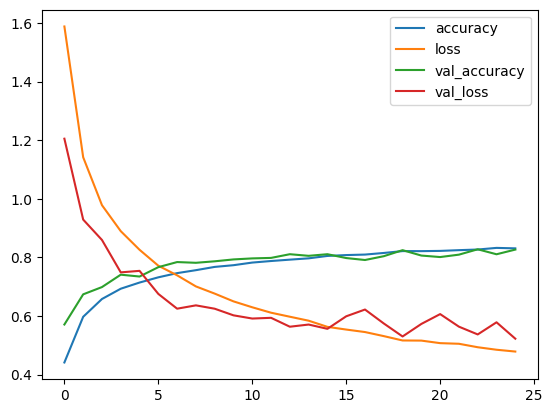

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

pd.DataFrame(history.history).plot()
plt.show()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 590,371 (2.25 MB)

 Trainable params: 590,371 (2.25 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 70s 361ms/step - accuracy: 0.6963 - loss: 0.7022 - val_accuracy: 0.7970 - val_loss: 0.5152
Epoch 2/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 65s 343ms/step - accuracy: 0.8033 - loss: 0.4808 - val_accuracy: 0.8200 - val_loss: 0.4534
Epoch 3/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 82s 346ms/step - accuracy: 0.8397 - loss: 0.4098 - val_accuracy: 0.8593 - val_loss: 0.3402
Epoch 4/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 65s 345ms/step - accuracy: 0.8633 - loss: 0.3497 - val_accuracy: 0.8813 - val_loss: 0.3097
Epoch 5/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 65s 344ms/step - accuracy: 0.8823 - loss: 0.3045 - val_accuracy: 0.8837 - val_loss: 0.3131
Epoch 6/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 82s 347ms/step - accuracy: 0.8934 - loss: 0.2781 - val_accuracy: 0.8983 - val_loss: 0.2638
Epoch 7/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 82s 345ms/step - accuracy: 0.9013 - loss: 0.2542 - val_accuracy: 0.9010 - val_loss: 0.2472
Epoch 8/20
188/188 ━━━━━━━━━━━━━━━━━━━━ 81s 343ms/step - accuracy: 0.9144 - loss: 0

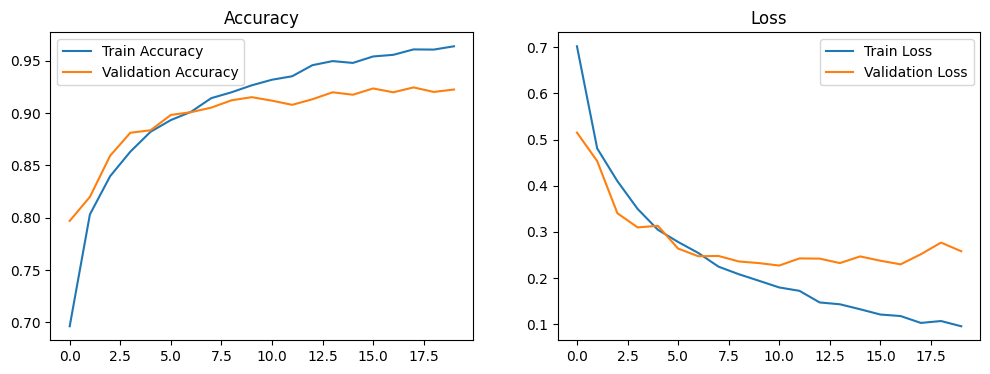

Модель успешно сохранена в файл: /content/cifar10_3class_cnn_model.h5


In [2]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import numpy as np
import os

# 1. Загрузка данных CIFAR-10
# Датасет содержит 60 000 изображений 32x32 в 10 классах (по 6 000 на класс)
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

# 2. Фильтрация по выбранным классам: 0 - самолёт, 1 - автомобиль, 2 - птица
# Используем np.isin для создания масок, чтобы оставить только нужные классы
classes = [0, 1, 2]
mask_train = np.isin(y_train, classes).flatten()
mask_test = np.isin(y_test, classes).flatten()
x_train, y_train = x_train[mask_train], y_train[mask_train]
x_test, y_test = x_test[mask_test], y_test[mask_test]

# 3. Нормализация данных
# Приводим значения пикселей к диапазону [0, 1] для ускорения обучения и стабильности градиентов
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# 4. Преобразование меток в one-hot encoding
# Для многоклассовой классификации с softmax на выходе
y_train = to_categorical(y_train, num_classes=3)
y_test = to_categorical(y_test, num_classes=3)

# 5. Построение CNN
model = models.Sequential([
    # Первый блок свёртки: 32 фильтра, ядро 3x3, ReLU-активация, same padding
    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    # Второй слой свёртки с теми же параметрами для углубления признаков
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    # MaxPooling уменьшает размерность карт признаков (2x2), ускоряет обучение
    layers.MaxPooling2D((2,2)),
    # Dropout (25%) — регуляризация для предотвращения переобучения
    layers.Dropout(0.25),

    # Второй блок свёртки: 64 фильтра для выделения более сложных признаков
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    # Преобразование двумерных карт признаков в вектор для полносвязных слоёв
    layers.Flatten(),

    # Полносвязный слой: 128 нейронов, ReLU-активация
    layers.Dense(128, activation='relu'),
    # Dropout (50%) — сильная регуляризация перед выходным слоем
    layers.Dropout(0.5),

    # Выходной слой: 3 нейрона (по числу классов), softmax для вероятностей классов
    layers.Dense(3, activation='softmax')
])

# 6. Компиляция модели
# Оптимизатор Adam — адаптивный метод градиентного спуска, хорошо подходит для большинства задач
# Функция потерь categorical_crossentropy — стандарт для многоклассовой классификации
# Метрика accuracy — доля правильно классифицированных примеров
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Вывод структуры модели (для анализа архитектуры)
model.summary()

# 7. Обучение модели
# epochs=20 — количество проходов по всему обучающему набору
# batch_size=64 — число примеров в одной итерации обновления весов
# validation_split=0.2 — 20% обучающих данных используется для валидации
history = model.fit(x_train, y_train,
                    epochs=20,
                    batch_size=64,
                    validation_split=0.2,
                    verbose=1) # verbose=1 — подробный вывод процесса обучения

# 8. Оценка на тестовых данных
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Точность на тесте: {test_acc:.4f}")

# 9. Визуализация обучения
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.legend()
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.legend()
plt.show()

# 10. Сохранение обученной модели в файл HDF5 (.h5)
model_path = 'cifar10_3class_cnn_model.h5'
model.save(model_path)
print(f"Модель успешно сохранена в файл: {os.path.abspath(model_path)}")